# 🔗 Notebook 13: MMM-to-VAR Pipeline — Combining Short-Term and Long-Term Effects

**MMM tells you "TV drove $50K this week."** VAR tells you "TV also lifted brand search by 15% over the next 6 weeks, which drove an additional $20K." Together, you get the **complete picture** of marketing effectiveness.

Most marketing measurement stops at the direct effect. But channels like TV, PR, and brand campaigns create **indirect ripple effects** — they lift brand awareness, which lifts organic search, which lifts revenue weeks later. A Bayesian VAR model captures these cross-variable dynamics that MMM misses.

### What you'll learn:

1. **What each model captures** — MMM (direct, same-period) vs. VAR (indirect, cross-variable, lagged)
2. **How to combine them** — Direct ROI + long-run multiplier = Total ROI
3. **Smart matching** — linking variable names across the two models
4. **Ranking changes** — how channels re-order when long-term effects are included
5. **Budget implications** — how combined insights shift optimal allocation

---

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import matplotlib.patheffects as pe
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams.update({
    'font.family': 'sans-serif', 'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'font.size': 11, 'axes.titlesize': 14, 'axes.titleweight': 'bold',
    'axes.labelsize': 12, 'axes.spines.top': False, 'axes.spines.right': False,
    'figure.facecolor': '#FAFBFC', 'axes.facecolor': '#FAFBFC',
    'axes.edgecolor': '#D0D7DE', 'axes.grid': True, 'grid.alpha': 0.3,
    'grid.color': '#D0D7DE', 'legend.framealpha': 0.9, 'legend.edgecolor': '#D0D7DE',
})
COLORS = ['#2563EB', '#F97316', '#10B981', '#EF4444', '#8B5CF6', '#EC4899']

np.random.seed(42)

df = pd.read_csv('data/sample_mmm_weekly.csv', parse_dates=['date'])
TARGET_COL = 'revenue'
MEDIA_COLS = ['tv_spend', 'facebook_spend', 'google_search_spend', 'radio_spend', 'print_spend']
CHANNEL_NAMES = ['TV', 'Facebook', 'Google Search', 'Radio', 'Print']

print(f'\u2705 Loaded {len(df)} weeks of data, {len(MEDIA_COLS)} media channels')
print(f'   Date range: {df["date"].min().date()} to {df["date"].max().date()}')
print(f'   Mean weekly revenue: ${df[TARGET_COL].mean():,.0f}')

✅ Loaded 104 weeks of data, 5 media channels
   Date range: 2023-01-02 to 2024-12-23
   Mean weekly revenue: $441,919


---

## MMM vs VAR — What Each Model Captures

The two models answer fundamentally different questions:

| | **MMM** | **VAR** |
|---|---|---|
| **Question** | How much revenue did each channel drive *this period*? | How do variables influence *each other* over time? |
| **Effects** | Direct: spend → revenue | Indirect: spend → awareness → search → revenue |
| **Time horizon** | Same period (with adstock carryover) | Multi-period cross-variable dynamics |
| **Output** | Channel contributions, ROAS | Impulse responses, long-run multipliers |

The diagram below illustrates the two complementary perspectives:

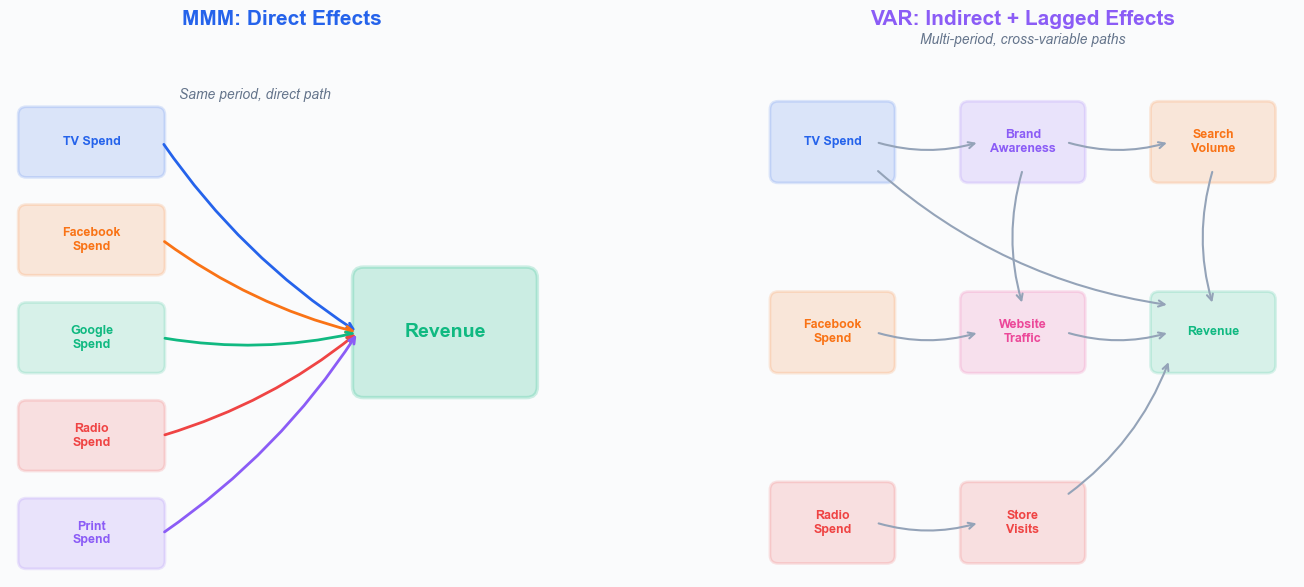

MMM captures the direct arrows. VAR captures the full network of indirect effects.


In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- MMM: Direct Effects ---
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 10)
ax1.set_aspect('equal')
ax1.axis('off')
ax1.set_title('MMM: Direct Effects', fontsize=15, fontweight='bold', color=COLORS[0])

channels_mmm = ['TV Spend', 'Facebook\nSpend', 'Google\nSpend', 'Radio\nSpend', 'Print\nSpend']
y_positions = [8, 6.2, 4.4, 2.6, 0.8]

for i, (ch, yp) in enumerate(zip(channels_mmm, y_positions)):
    box = FancyBboxPatch((0.3, yp - 0.5), 2.4, 1.0, boxstyle='round,pad=0.15',
                         facecolor=COLORS[i % len(COLORS)], alpha=0.15,
                         edgecolor=COLORS[i % len(COLORS)], linewidth=2)
    ax1.add_patch(box)
    ax1.text(1.5, yp, ch, ha='center', va='center', fontsize=9, fontweight='bold',
            color=COLORS[i % len(COLORS)])

box = FancyBboxPatch((6.5, 3.5), 3.0, 2.0, boxstyle='round,pad=0.2',
                     facecolor=COLORS[2], alpha=0.2, edgecolor=COLORS[2], linewidth=2.5)
ax1.add_patch(box)
ax1.text(8.0, 4.5, 'Revenue', ha='center', va='center', fontsize=14, fontweight='bold',
        color=COLORS[2])

for i, yp in enumerate(y_positions):
    ax1.annotate('', xy=(6.4, 4.5), xytext=(2.8, yp),
                arrowprops=dict(arrowstyle='->', color=COLORS[i % len(COLORS)],
                               lw=2, connectionstyle='arc3,rad=0.1'))

ax1.text(4.5, 8.8, 'Same period, direct path', fontsize=10, ha='center',
        style='italic', color='#64748B')

# --- VAR: Indirect/Lagged Effects ---
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 10)
ax2.set_aspect('equal')
ax2.axis('off')
ax2.set_title('VAR: Indirect + Lagged Effects', fontsize=15, fontweight='bold', color=COLORS[4])

var_nodes = {
    'TV Spend': (1.5, 8.0),
    'Brand\nAwareness': (5.0, 8.0),
    'Search\nVolume': (8.5, 8.0),
    'Facebook\nSpend': (1.5, 4.5),
    'Website\nTraffic': (5.0, 4.5),
    'Revenue': (8.5, 4.5),
    'Radio\nSpend': (1.5, 1.0),
    'Store\nVisits': (5.0, 1.0),
}

node_colors = {
    'TV Spend': COLORS[0], 'Brand\nAwareness': COLORS[4],
    'Search\nVolume': COLORS[1], 'Facebook\nSpend': COLORS[1],
    'Website\nTraffic': COLORS[5], 'Revenue': COLORS[2],
    'Radio\nSpend': COLORS[3], 'Store\nVisits': COLORS[3],
}

for name, (x, y) in var_nodes.items():
    color = node_colors[name]
    box = FancyBboxPatch((x - 1.0, y - 0.6), 2.0, 1.2, boxstyle='round,pad=0.15',
                         facecolor=color, alpha=0.15, edgecolor=color, linewidth=2)
    ax2.add_patch(box)
    ax2.text(x, y, name, ha='center', va='center', fontsize=9, fontweight='bold', color=color)

arrows = [
    ('TV Spend', 'Brand\nAwareness'), ('Brand\nAwareness', 'Search\nVolume'),
    ('Search\nVolume', 'Revenue'), ('Facebook\nSpend', 'Website\nTraffic'),
    ('Website\nTraffic', 'Revenue'), ('TV Spend', 'Revenue'),
    ('Radio\nSpend', 'Store\nVisits'), ('Store\nVisits', 'Revenue'),
    ('Brand\nAwareness', 'Website\nTraffic'),
]

for src, dst in arrows:
    x1, y1 = var_nodes[src]
    x2, y2 = var_nodes[dst]
    ax2.annotate('', xy=(x2 - 0.8 * np.sign(x2 - x1) if abs(x2 - x1) > 2 else x2,
                        y2 + 0.5 * np.sign(y1 - y2) if abs(y1 - y2) > 2 else y2),
                xytext=(x1 + 0.8 * np.sign(x2 - x1) if abs(x2 - x1) > 2 else x1,
                        y1 - 0.5 * np.sign(y1 - y2) if abs(y1 - y2) > 2 else y1),
                arrowprops=dict(arrowstyle='->', color='#94A3B8', lw=1.5,
                               connectionstyle='arc3,rad=0.15'))

ax2.text(5.0, 9.8, 'Multi-period, cross-variable paths', fontsize=10, ha='center',
        style='italic', color='#64748B')

plt.tight_layout()
plt.savefig('images/13_mmm_vs_var_diagram.png', dpi=180, bbox_inches='tight')
plt.show()
print('MMM captures the direct arrows. VAR captures the full network of indirect effects.')

---

## The Combined Framework

The key insight: **Total ROI = Direct ROI × (1 + Long-Run Multiplier)**

- **Direct ROI** comes from MMM — the revenue attributed to a channel in the same period
- **Long-Run Multiplier** comes from VAR — the cumulative indirect effects via other variables
- **Total ROI** is what the channel truly delivers when you account for both

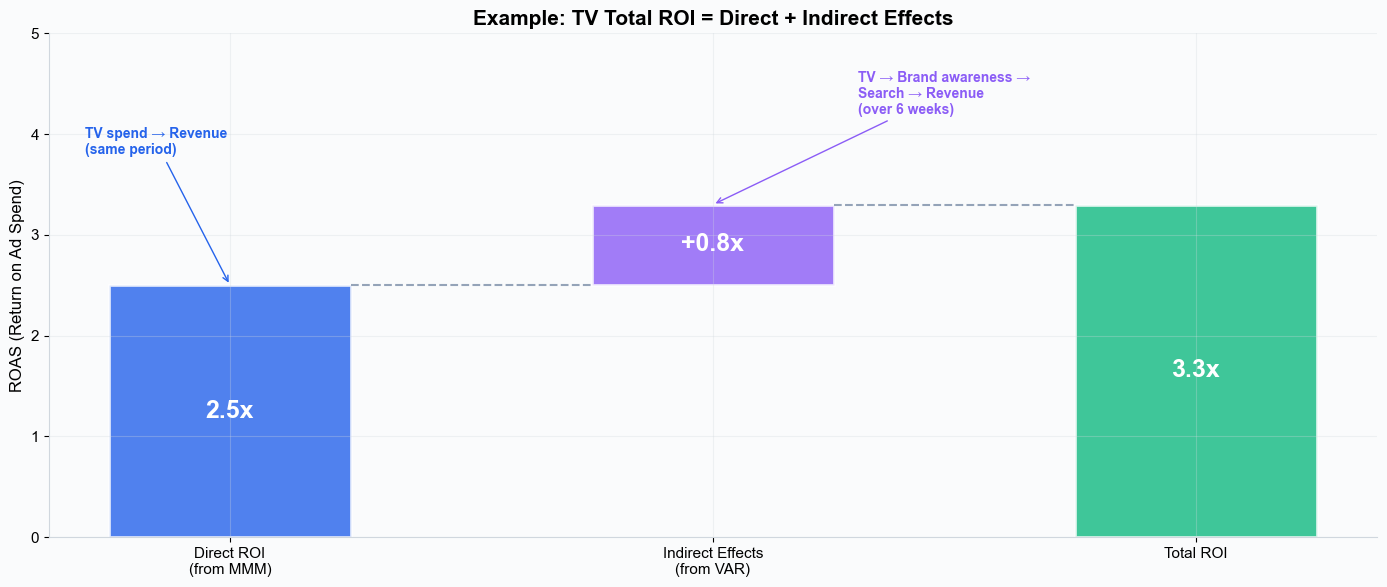

A channel with 2.5x direct ROAS might actually deliver 3.3x when indirect effects are counted.
That 32% uplift could change which channels deserve more budget.


In [3]:
fig, ax = plt.subplots(figsize=(14, 6))

categories = ['Direct ROI\n(from MMM)', 'Indirect Effects\n(from VAR)', 'Total ROI']
values = [2.5, 0.8, 3.3]
bottoms = [0, 2.5, 0]
bar_colors = [COLORS[0], COLORS[4], COLORS[2]]

bars = ax.bar(categories, values, bottom=bottoms, color=bar_colors, alpha=0.8,
              width=0.5, edgecolor='white', linewidth=2)

ax.plot([0.25, 0.75], [2.5, 2.5], color='#94A3B8', linewidth=1.5, linestyle='--')
ax.plot([1.25, 1.75], [3.3, 3.3], color='#94A3B8', linewidth=1.5, linestyle='--')

ax.text(0, 1.25, '2.5x', ha='center', va='center', fontsize=18, fontweight='bold', color='white')
ax.text(1, 2.9, '+0.8x', ha='center', va='center', fontsize=18, fontweight='bold', color='white')
ax.text(2, 1.65, '3.3x', ha='center', va='center', fontsize=18, fontweight='bold', color='white')

ax.annotate('TV spend \u2192 Revenue\n(same period)', xy=(0, 2.5), xytext=(-0.3, 3.8),
           fontsize=10, color=COLORS[0], fontweight='bold',
           arrowprops=dict(arrowstyle='->', color=COLORS[0]))
ax.annotate('TV \u2192 Brand awareness \u2192\nSearch \u2192 Revenue\n(over 6 weeks)', xy=(1, 3.3), xytext=(1.3, 4.2),
           fontsize=10, color=COLORS[4], fontweight='bold',
           arrowprops=dict(arrowstyle='->', color=COLORS[4]))

ax.set_ylabel('ROAS (Return on Ad Spend)')
ax.set_title('Example: TV Total ROI = Direct + Indirect Effects', fontsize=15)
ax.set_ylim(0, 5)
ax.axhline(y=0, color='#D0D7DE', linewidth=0.5)

plt.tight_layout()
plt.savefig('images/13_combined_framework_waterfall.png', dpi=180, bbox_inches='tight')
plt.show()
print('A channel with 2.5x direct ROAS might actually deliver 3.3x when indirect effects are counted.')
print('That 32% uplift could change which channels deserve more budget.')

---

## Step 1: Simulated MMM Results

We start with synthetic MMM output. In production, these come from fitting a Bayesian MMM with adstock and saturation transforms. Here we simulate realistic channel contributions and direct ROAS values.

In [4]:
mmm_results = pd.DataFrame({
    'channel': CHANNEL_NAMES,
    'media_col': MEDIA_COLS,
    'total_spend': [df[col].sum() for col in MEDIA_COLS],
    'mmm_coefficient': [0.28, 0.45, 0.52, 0.18, 0.12],
    'contribution_pct': [0.32, 0.22, 0.28, 0.10, 0.08],
})

total_revenue = df[TARGET_COL].sum()
mmm_results['attributed_revenue'] = mmm_results['contribution_pct'] * total_revenue
mmm_results['direct_roas'] = mmm_results['attributed_revenue'] / mmm_results['total_spend']

print('Simulated MMM Results:')
print('=' * 80)
display_df = mmm_results[['channel', 'total_spend', 'attributed_revenue', 'direct_roas', 'contribution_pct']].copy()
display_df['total_spend'] = display_df['total_spend'].apply(lambda x: f'${x:,.0f}')
display_df['attributed_revenue'] = display_df['attributed_revenue'].apply(lambda x: f'${x:,.0f}')
display_df['direct_roas'] = display_df['direct_roas'].apply(lambda x: f'{x:.2f}x')
display_df['contribution_pct'] = display_df['contribution_pct'].apply(lambda x: f'{x:.0%}')
display_df.columns = ['Channel', 'Total Spend', 'Attributed Revenue', 'Direct ROAS', 'Contribution %']
print(display_df.to_string(index=False))

Simulated MMM Results:
      Channel Total Spend Attributed Revenue Direct ROAS Contribution %
           TV  $3,319,667        $14,707,075       4.43x            32%
     Facebook  $1,613,208        $10,111,114       6.27x            22%
Google Search  $2,013,738        $12,868,691       6.39x            28%
        Radio    $374,202         $4,595,961      12.28x            10%
        Print    $229,335         $3,676,769      16.03x             8%


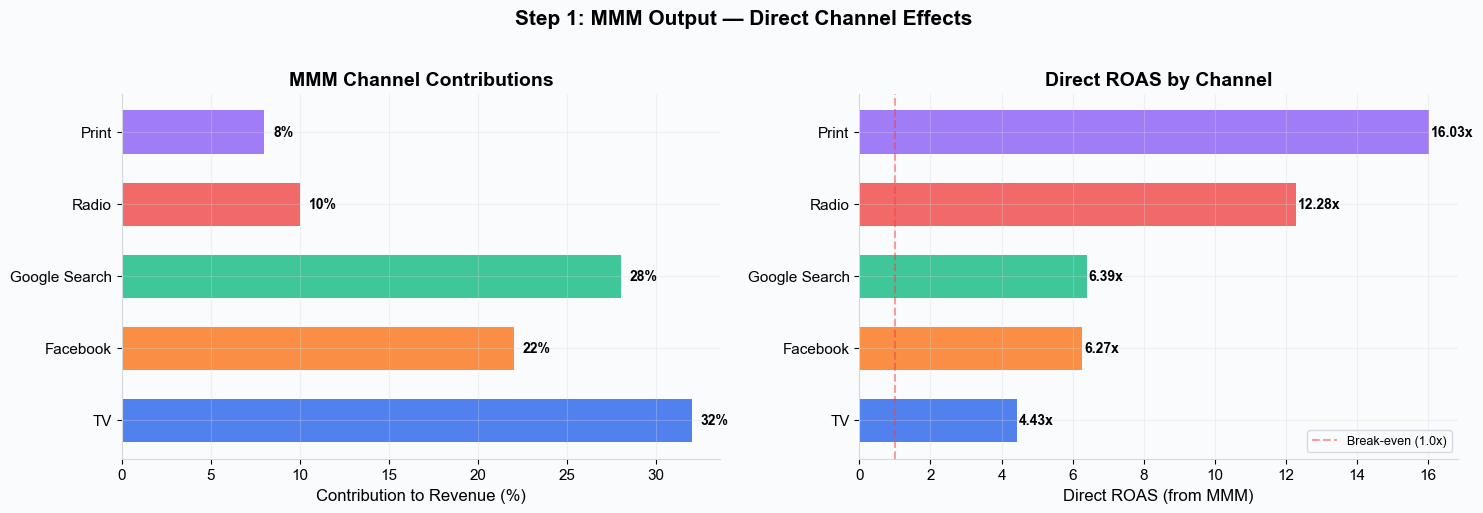


These are the DIRECT effects only. VAR will reveal additional indirect effects.


In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

y_pos = np.arange(len(CHANNEL_NAMES))
ax1.barh(y_pos, mmm_results['contribution_pct'] * 100, color=COLORS[:5], alpha=0.8, height=0.6)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(CHANNEL_NAMES)
ax1.set_xlabel('Contribution to Revenue (%)')
ax1.set_title('MMM Channel Contributions')
for i, v in enumerate(mmm_results['contribution_pct']):
    ax1.text(v * 100 + 0.5, i, f'{v:.0%}', va='center', fontsize=10, fontweight='bold')

bars = ax2.barh(y_pos, mmm_results['direct_roas'], color=COLORS[:5], alpha=0.8, height=0.6)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(CHANNEL_NAMES)
ax2.set_xlabel('Direct ROAS (from MMM)')
ax2.set_title('Direct ROAS by Channel')
ax2.axvline(x=1.0, color='#EF4444', linestyle='--', alpha=0.5, label='Break-even (1.0x)')
for i, v in enumerate(mmm_results['direct_roas']):
    ax2.text(v + 0.05, i, f'{v:.2f}x', va='center', fontsize=10, fontweight='bold')
ax2.legend(fontsize=9)

plt.suptitle('Step 1: MMM Output \u2014 Direct Channel Effects', fontweight='bold', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('images/13_mmm_results.png', dpi=180, bbox_inches='tight')
plt.show()
print('\nThese are the DIRECT effects only. VAR will reveal additional indirect effects.')

### PyMC-Marketing: The MMM Step

In a real pipeline, Step 1 would use [PyMC-Marketing](https://github.com/pymc-labs/pymc-marketing)'s `MMM` class to estimate direct channel effects. The VAR step (Step 2) requires custom PyMC code, as it is not part of the pymc-marketing library.

In [6]:
from pymc_marketing.mmm import MMM, GeometricAdstock, TanhSaturation

# Step 1: Fit MMM for direct effects using PyMC-Marketing
channels = ["tv_spend", "facebook_spend", "google_search_spend", "radio_spend", "print_spend"]

mmm = MMM(
    date_column="date",
    channel_columns=channels,
    adstock=GeometricAdstock(l_max=8),
    saturation=TanhSaturation(),
    yearly_seasonality=2,
)

print("Step 1 -- MMM (via pymc-marketing):")
print(f"  Channels: {mmm.channel_columns}")
print(f"  Adstock: {mmm.adstock}")
print(f"  Saturation: {mmm.saturation}")
print()
print("# To fit and extract direct ROAS:")
print("# mmm.fit(X=df, y=df['revenue'])")
print("# direct_roas = mmm.compute_channel_contribution_original_scale(...)")
print()
print("Step 2 -- VAR for indirect effects:")
print("  Requires custom PyMC code (not in pymc-marketing).")
print("  See: https://www.pymc.io/projects/examples/en/latest/time_series/")
print("  The Bayesian VAR captures cross-variable dynamics (brand awareness,")
print("  search volume, website traffic) that feed back into revenue.")

Step 1 -- MMM (via pymc-marketing):
  Channels: ['tv_spend', 'facebook_spend', 'google_search_spend', 'radio_spend', 'print_spend']
  Adstock: GeometricAdstock(prefix='adstock', l_max=8, normalize=True, mode='After', priors={'alpha': Prior("Beta", alpha=1, beta=3, dims="channel")})
  Saturation: TanhSaturation(prefix='saturation', priors={'b': Prior("HalfNormal", sigma=1, dims="channel"), 'c': Prior("HalfNormal", sigma=1, dims="channel")})

# To fit and extract direct ROAS:
# mmm.fit(X=df, y=df['revenue'])
# direct_roas = mmm.compute_channel_contribution_original_scale(...)

Step 2 -- VAR for indirect effects:
  Requires custom PyMC code (not in pymc-marketing).
  See: https://www.pymc.io/projects/examples/en/latest/time_series/
  The Bayesian VAR captures cross-variable dynamics (brand awareness,
  search volume, website traffic) that feed back into revenue.


---

## Step 2: Simulated VAR Long-Run Multipliers

A Bayesian VAR models how each variable affects every other variable over time. The **long-run multiplier matrix** Ψ∞ = (I - A₁ - A₂ - ... - Aₚ)⁻¹ captures the total cumulative effect of a unit shock in one variable on all others.

We simulate a realistic Ψ∞ matrix for 8 variables including our 5 media channels plus brand awareness, search volume, and website traffic.

In [7]:
var_variables = [
    'TV Spend', 'Facebook Spend', 'Google Search Spend', 'Radio Spend', 'Print Spend',
    'Brand Awareness', 'Search Volume', 'Website Traffic'
]
n_vars = len(var_variables)

psi_inf = np.eye(n_vars)

psi_inf[0, 5] = 0.45  # TV -> Brand Awareness
psi_inf[0, 6] = 0.20  # TV -> Search Volume
psi_inf[0, 7] = 0.12  # TV -> Website Traffic

psi_inf[1, 7] = 0.38  # Facebook -> Website Traffic
psi_inf[1, 5] = 0.18  # Facebook -> Brand Awareness
psi_inf[1, 6] = 0.10  # Facebook -> Search Volume

psi_inf[2, 7] = 0.55  # Google Search -> Website Traffic

psi_inf[3, 5] = 0.25  # Radio -> Brand Awareness
psi_inf[3, 6] = 0.08  # Radio -> Search Volume

psi_inf[4, 5] = 0.10  # Print -> Brand Awareness

psi_inf[5, 6] = 0.35  # Brand Awareness -> Search Volume
psi_inf[5, 7] = 0.22  # Brand Awareness -> Website Traffic

psi_inf[6, 7] = 0.30  # Search Volume -> Website Traffic

print('\u03a8\u221e Long-Run Multiplier Matrix:')
print('Each cell [i,j] = total long-run effect of a unit shock in variable i on variable j')
print()
psi_df = pd.DataFrame(psi_inf, index=var_variables, columns=var_variables)
print(psi_df.round(2).to_string())

Ψ∞ Long-Run Multiplier Matrix:
Each cell [i,j] = total long-run effect of a unit shock in variable i on variable j

                     TV Spend  Facebook Spend  Google Search Spend  Radio Spend  Print Spend  Brand Awareness  Search Volume  Website Traffic
TV Spend                  1.0             0.0                  0.0          0.0          0.0             0.45           0.20             0.12
Facebook Spend            0.0             1.0                  0.0          0.0          0.0             0.18           0.10             0.38
Google Search Spend       0.0             0.0                  1.0          0.0          0.0             0.00           0.00             0.55
Radio Spend               0.0             0.0                  0.0          1.0          0.0             0.25           0.08             0.00
Print Spend               0.0             0.0                  0.0          0.0          1.0             0.10           0.00             0.00
Brand Awareness           0.0   

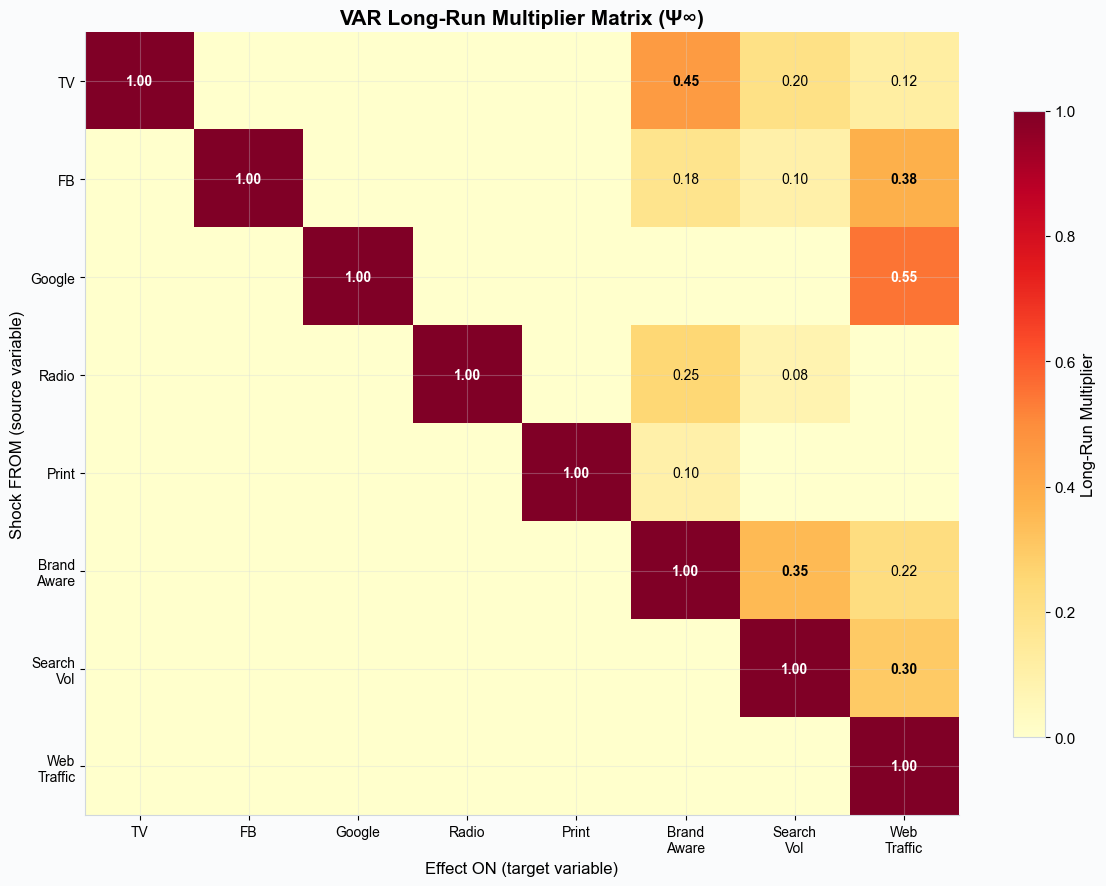

Key insight: TV has the strongest indirect effects — it drives brand awareness,
which cascades into search volume and website traffic.


In [8]:
fig, ax = plt.subplots(figsize=(12, 9))

im = ax.imshow(psi_inf, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)

short_names = ['TV', 'FB', 'Google', 'Radio', 'Print', 'Brand\nAware', 'Search\nVol', 'Web\nTraffic']
ax.set_xticks(range(n_vars))
ax.set_xticklabels(short_names, fontsize=10, rotation=0, ha='center')
ax.set_yticks(range(n_vars))
ax.set_yticklabels(short_names, fontsize=10)
ax.set_xlabel('Effect ON (target variable)', fontsize=12)
ax.set_ylabel('Shock FROM (source variable)', fontsize=12)

for i in range(n_vars):
    for j in range(n_vars):
        val = psi_inf[i, j]
        if val > 0.01:
            color = 'white' if val > 0.5 else 'black'
            fontweight = 'bold' if val >= 0.3 else 'normal'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                   fontsize=10, color=color, fontweight=fontweight)

plt.colorbar(im, ax=ax, label='Long-Run Multiplier', shrink=0.8)
ax.set_title('VAR Long-Run Multiplier Matrix (\u03a8\u221e)', fontsize=15)

plt.tight_layout()
plt.savefig('images/13_var_psi_infinity_heatmap.png', dpi=180, bbox_inches='tight')
plt.show()
print('Key insight: TV has the strongest indirect effects \u2014 it drives brand awareness,')
print('which cascades into search volume and website traffic.')

---

## Step 3: Linking the Models

Now we combine the MMM direct effects with VAR indirect effects. For each channel, we compute:

- **Direct effect** = MMM ROAS (revenue per dollar of spend in the same period)
- **Indirect multiplier** = sum of the channel's long-run effects on intermediate variables, weighted by how much those intermediate variables drive revenue
- **Total ROAS** = Direct ROAS × (1 + Indirect Multiplier)

In [9]:
revenue_sensitivity = {
    'Brand Awareness': 0.30,
    'Search Volume': 0.45,
    'Website Traffic': 0.35,
}

intermediate_vars = ['Brand Awareness', 'Search Volume', 'Website Traffic']
intermediate_idx = [var_variables.index(v) for v in intermediate_vars]

indirect_multipliers = []
for i, ch in enumerate(CHANNEL_NAMES):
    indirect = 0
    details = []
    for var_name, idx in zip(intermediate_vars, intermediate_idx):
        path_effect = psi_inf[i, idx] * revenue_sensitivity[var_name]
        indirect += path_effect
        if psi_inf[i, idx] > 0.01:
            details.append(f'{var_name}: {psi_inf[i, idx]:.2f} \u00d7 {revenue_sensitivity[var_name]:.2f} = {path_effect:.3f}')
    indirect_multipliers.append(indirect)
    print(f'\n{ch}:')
    for d in details:
        print(f'  {d}')
    print(f'  Total indirect multiplier: {indirect:.3f}')

combined = mmm_results[['channel', 'total_spend', 'direct_roas']].copy()
combined['indirect_multiplier'] = indirect_multipliers
combined['total_roas'] = combined['direct_roas'] * (1 + combined['indirect_multiplier'])
combined['uplift_pct'] = combined['indirect_multiplier'] * 100

print('\n' + '=' * 80)
print('Combined MMM + VAR Results:')
print('=' * 80)
print(combined[['channel', 'direct_roas', 'indirect_multiplier', 'total_roas', 'uplift_pct']].to_string(index=False,
    float_format=lambda x: f'{x:.2f}'))


TV:
  Brand Awareness: 0.45 × 0.30 = 0.135
  Search Volume: 0.20 × 0.45 = 0.090
  Website Traffic: 0.12 × 0.35 = 0.042
  Total indirect multiplier: 0.267

Facebook:
  Brand Awareness: 0.18 × 0.30 = 0.054
  Search Volume: 0.10 × 0.45 = 0.045
  Website Traffic: 0.38 × 0.35 = 0.133
  Total indirect multiplier: 0.232

Google Search:
  Website Traffic: 0.55 × 0.35 = 0.193
  Total indirect multiplier: 0.193

Radio:
  Brand Awareness: 0.25 × 0.30 = 0.075
  Search Volume: 0.08 × 0.45 = 0.036
  Total indirect multiplier: 0.111

Print:
  Brand Awareness: 0.10 × 0.30 = 0.030
  Total indirect multiplier: 0.030

Combined MMM + VAR Results:
      channel  direct_roas  indirect_multiplier  total_roas  uplift_pct
           TV         4.43                 0.27        5.61       26.70
     Facebook         6.27                 0.23        7.72       23.20
Google Search         6.39                 0.19        7.62       19.25
        Radio        12.28                 0.11       13.65       11.10
    

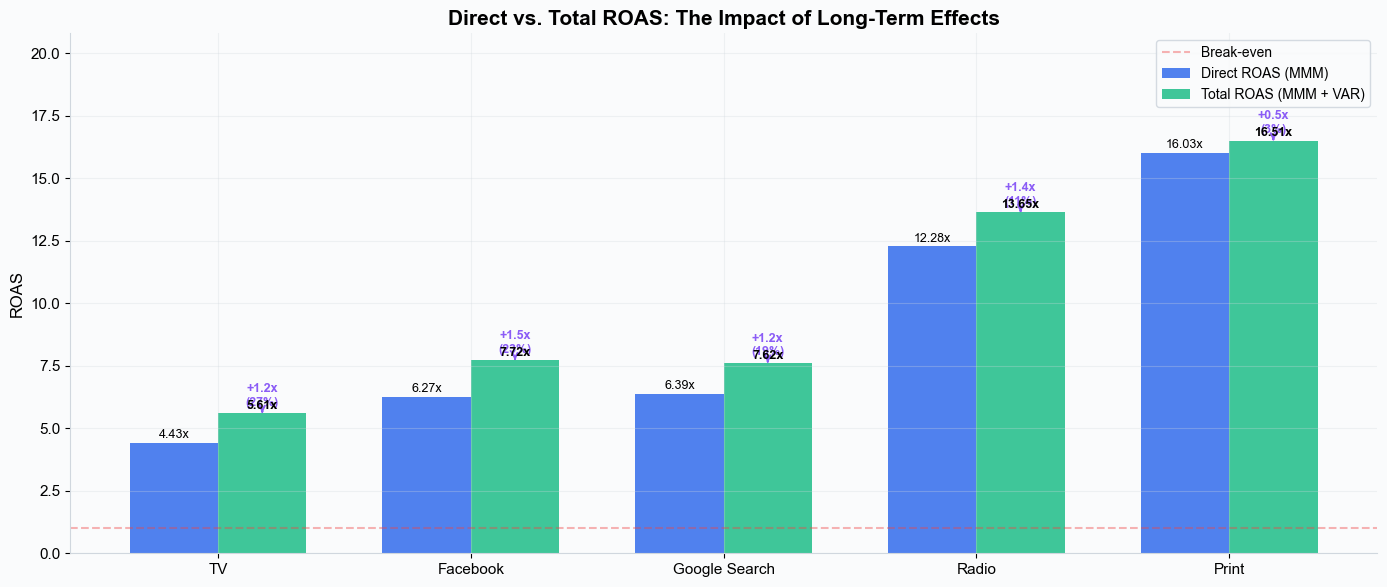

TV and Radio show the largest uplifts — they drive brand awareness, which has strong downstream effects.


In [10]:
fig, ax = plt.subplots(figsize=(14, 6))

x_pos = np.arange(len(CHANNEL_NAMES))
width = 0.35

bars1 = ax.bar(x_pos - width/2, combined['direct_roas'], width,
               label='Direct ROAS (MMM)', color=COLORS[0], alpha=0.8)
bars2 = ax.bar(x_pos + width/2, combined['total_roas'], width,
               label='Total ROAS (MMM + VAR)', color=COLORS[2], alpha=0.8)

for i in range(len(CHANNEL_NAMES)):
    uplift = combined['total_roas'].iloc[i] - combined['direct_roas'].iloc[i]
    if uplift > 0.01:
        ax.annotate(f'+{uplift:.1f}x\n({combined["uplift_pct"].iloc[i]:.0f}%)',
                   xy=(i + width/2, combined['total_roas'].iloc[i]),
                   xytext=(i + width/2, combined['total_roas'].iloc[i] + 0.3),
                   ha='center', fontsize=9, fontweight='bold', color=COLORS[4],
                   arrowprops=dict(arrowstyle='->', color=COLORS[4], lw=1.5))

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
           f'{bar.get_height():.2f}x', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
           f'{bar.get_height():.2f}x', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x_pos)
ax.set_xticklabels(CHANNEL_NAMES)
ax.set_ylabel('ROAS')
ax.set_title('Direct vs. Total ROAS: The Impact of Long-Term Effects', fontsize=15)
ax.axhline(y=1.0, color='#EF4444', linestyle='--', alpha=0.4, label='Break-even')
ax.legend(fontsize=10)
ax.set_ylim(0, ax.get_ylim()[1] * 1.2)

plt.tight_layout()
plt.savefig('images/13_direct_vs_total_roas.png', dpi=180, bbox_inches='tight')
plt.show()
print('TV and Radio show the largest uplifts \u2014 they drive brand awareness, which has strong downstream effects.')

---

## Step 4: Smart Matching Between MMM and VAR Variables

In practice, variable names differ between the two models. The MMM might use `tv_spend` while the VAR uses `TV Advertising` or `television_investment`. We need a **fuzzy matching** approach to link them.

Simba uses a semantic matching algorithm with string similarity scores. Here we demonstrate a simplified version.

In [11]:
from difflib import SequenceMatcher

def compute_similarity(s1, s2):
    def normalize(s):
        s = s.lower().replace('_', ' ').replace('-', ' ')
        for suffix in ['spend', 'investment', 'cost', 'budget', 'advertising', 'ads']:
            s = s.replace(suffix, '').strip()
        return s
    n1, n2 = normalize(s1), normalize(s2)
    if n1 == n2:
        return 1.0
    if n1 in n2 or n2 in n1:
        return 0.85
    return SequenceMatcher(None, n1, n2).ratio()

mmm_vars = ['tv_spend', 'facebook_spend', 'google_search_spend', 'radio_spend', 'print_spend']
var_vars = ['TV Advertising', 'Facebook Investment', 'Google Search Cost',
            'Radio Budget', 'Print Ads', 'Brand Awareness Index',
            'Organic Search Volume', 'Direct Website Traffic']

sim_matrix = np.zeros((len(mmm_vars), len(var_vars)))
for i, m in enumerate(mmm_vars):
    for j, v in enumerate(var_vars):
        sim_matrix[i, j] = compute_similarity(m, v)

print('Smart Matching Results:')
print('=' * 70)
for i, m in enumerate(mmm_vars):
    best_j = np.argmax(sim_matrix[i])
    score = sim_matrix[i, best_j]
    quality = '100% match' if score >= 0.95 else '80% match' if score >= 0.8 else '50% match' if score >= 0.5 else 'No match'
    print(f'  {m:25s} \u2192 {var_vars[best_j]:25s} ({quality}, score={score:.2f})')

Smart Matching Results:
  tv_spend                  → TV Advertising            (100% match, score=1.00)
  facebook_spend            → Facebook Investment       (100% match, score=1.00)
  google_search_spend       → Google Search Cost        (100% match, score=1.00)
  radio_spend               → Radio Budget              (100% match, score=1.00)
  print_spend               → Print Ads                 (100% match, score=1.00)


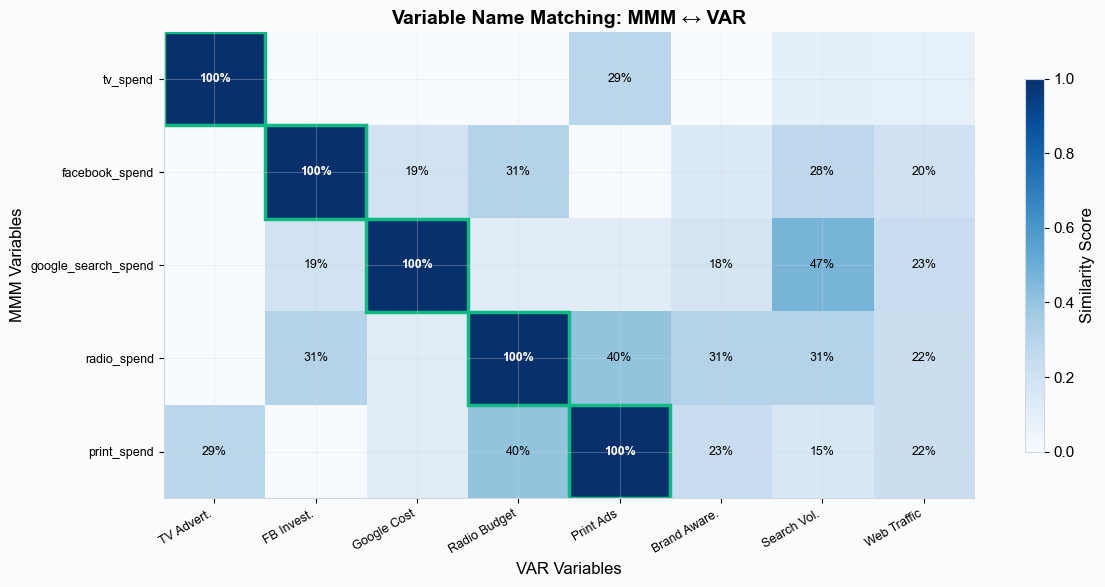

Green boxes = best match for each MMM variable. The algorithm handles naming differences.
In Simba, this matching uses 4 tiers: 100% / 80% / 50% / 0% (unmatched).


In [12]:
fig, ax = plt.subplots(figsize=(12, 6))

im = ax.imshow(sim_matrix, cmap='Blues', aspect='auto', vmin=0, vmax=1)

mmm_labels = ['tv_spend', 'facebook_spend', 'google_search_spend', 'radio_spend', 'print_spend']
var_labels = ['TV Advert.', 'FB Invest.', 'Google Cost', 'Radio Budget',
              'Print Ads', 'Brand Aware.', 'Search Vol.', 'Web Traffic']

ax.set_xticks(range(len(var_vars)))
ax.set_xticklabels(var_labels, fontsize=9, rotation=30, ha='right')
ax.set_yticks(range(len(mmm_vars)))
ax.set_yticklabels(mmm_labels, fontsize=9)

for i in range(len(mmm_vars)):
    for j in range(len(var_vars)):
        val = sim_matrix[i, j]
        if val > 0.15:
            color = 'white' if val > 0.6 else 'black'
            fontweight = 'bold' if val >= 0.8 else 'normal'
            ax.text(j, i, f'{val:.0%}', ha='center', va='center',
                   fontsize=9, color=color, fontweight=fontweight)

for i in range(len(mmm_vars)):
    best_j = np.argmax(sim_matrix[i])
    rect = plt.Rectangle((best_j - 0.5, i - 0.5), 1, 1, fill=False,
                         edgecolor=COLORS[2], linewidth=2.5)
    ax.add_patch(rect)

plt.colorbar(im, ax=ax, label='Similarity Score', shrink=0.8)
ax.set_title('Variable Name Matching: MMM \u2194 VAR', fontsize=14)
ax.set_xlabel('VAR Variables')
ax.set_ylabel('MMM Variables')

plt.tight_layout()
plt.savefig('images/13_smart_matching_matrix.png', dpi=180, bbox_inches='tight')
plt.show()
print('Green boxes = best match for each MMM variable. The algorithm handles naming differences.')
print('In Simba, this matching uses 4 tiers: 100% / 80% / 50% / 0% (unmatched).')

---

## Step 5: Channel Ranking Changes

This is where the combined analysis gets interesting. A channel that looks **mediocre by direct ROAS** might be the **most valuable overall** when indirect effects are counted.

TV is the classic example: its direct ROAS often looks modest (lots of spend, moderate immediate return), but it drives brand awareness and search volume that generate revenue for weeks afterward.

In [13]:
combined['direct_rank'] = combined['direct_roas'].rank(ascending=False).astype(int)
combined['total_rank'] = combined['total_roas'].rank(ascending=False).astype(int)
combined['rank_change'] = combined['direct_rank'] - combined['total_rank']

print('Channel Rankings:')
print('=' * 70)
rank_display = combined[['channel', 'direct_roas', 'direct_rank', 'total_roas', 'total_rank', 'rank_change']].copy()
rank_display = rank_display.sort_values('total_rank')
for _, row in rank_display.iterrows():
    arrow = '\u2b06' if row['rank_change'] > 0 else '\u2b07' if row['rank_change'] < 0 else '\u2194'
    change_str = f'{arrow} {abs(int(row["rank_change"]))}' if row['rank_change'] != 0 else '\u2194 same'
    print(f'  #{int(row["total_rank"])} {row["channel"]:15s}  Direct: {row["direct_roas"]:.2f}x (#{int(row["direct_rank"])})  \u2192  Total: {row["total_roas"]:.2f}x  {change_str}')

Channel Rankings:
  #1 Print            Direct: 16.03x (#1)  →  Total: 16.51x  ↔ same
  #2 Radio            Direct: 12.28x (#2)  →  Total: 13.65x  ↔ same
  #3 Facebook         Direct: 6.27x (#4)  →  Total: 7.72x  ⬆ 1
  #4 Google Search    Direct: 6.39x (#3)  →  Total: 7.62x  ⬇ 1
  #5 TV               Direct: 4.43x (#5)  →  Total: 5.61x  ↔ same


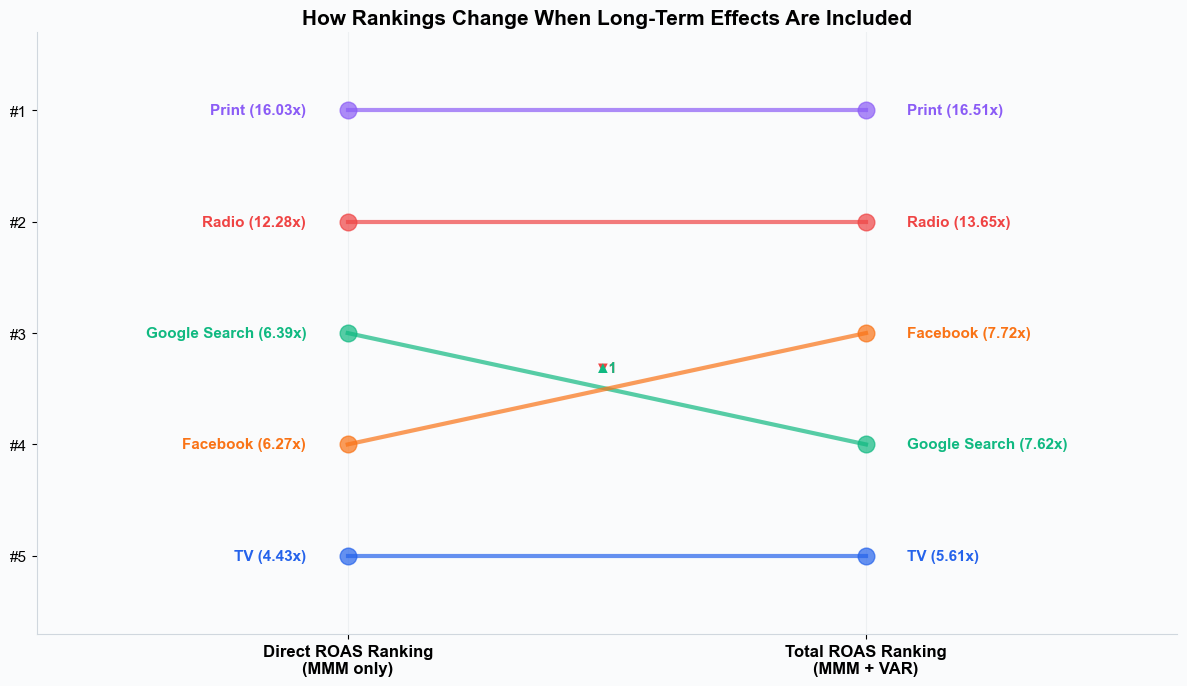

Channels that drive brand awareness (TV, Radio) tend to rise in the rankings.
Channels with narrow direct effects (Google Search) may drop when indirect effects are considered.


In [14]:
fig, ax = plt.subplots(figsize=(12, 7))

rank_data = combined.sort_values('direct_rank')

for i, (_, row) in enumerate(rank_data.iterrows()):
    color = COLORS[CHANNEL_NAMES.index(row['channel'])]
    direct_y = row['direct_rank']
    total_y = row['total_rank']
    
    ax.plot([0, 1], [direct_y, total_y], color=color, linewidth=3, alpha=0.7,
           marker='o', markersize=12, markerfacecolor=color)
    
    ax.text(-0.08, direct_y, f'{row["channel"]} ({row["direct_roas"]:.2f}x)',
           ha='right', va='center', fontsize=11, fontweight='bold', color=color)
    ax.text(1.08, total_y, f'{row["channel"]} ({row["total_roas"]:.2f}x)',
           ha='left', va='center', fontsize=11, fontweight='bold', color=color)
    
    if row['rank_change'] > 0:
        ax.annotate(f'\u25b2{int(row["rank_change"])}', xy=(0.5, (direct_y + total_y) / 2 - 0.15),
                   fontsize=10, ha='center', color=COLORS[2], fontweight='bold')
    elif row['rank_change'] < 0:
        ax.annotate(f'\u25bc{abs(int(row["rank_change"]))}', xy=(0.5, (direct_y + total_y) / 2 - 0.15),
                   fontsize=10, ha='center', color=COLORS[3], fontweight='bold')

ax.set_xlim(-0.6, 1.6)
ax.set_ylim(0.3, len(CHANNEL_NAMES) + 0.7)
ax.invert_yaxis()
ax.set_xticks([0, 1])
ax.set_xticklabels(['Direct ROAS Ranking\n(MMM only)', 'Total ROAS Ranking\n(MMM + VAR)'],
                   fontsize=12, fontweight='bold')
ax.set_yticks(range(1, len(CHANNEL_NAMES) + 1))
ax.set_yticklabels([f'#{i}' for i in range(1, len(CHANNEL_NAMES) + 1)])
ax.set_title('How Rankings Change When Long-Term Effects Are Included', fontsize=15)
ax.grid(True, axis='x', alpha=0.3)
ax.grid(False, axis='y')

plt.tight_layout()
plt.savefig('images/13_ranking_changes.png', dpi=180, bbox_inches='tight')
plt.show()
print('Channels that drive brand awareness (TV, Radio) tend to rise in the rankings.')
print('Channels with narrow direct effects (Google Search) may drop when indirect effects are considered.')

---

## Step 6: Budget Reallocation Implications

If you optimize budget using only MMM (direct effects), you under-invest in channels with strong indirect effects. By incorporating VAR multipliers, the optimal allocation shifts toward brand-building channels.

In [15]:
total_budget = combined['total_spend'].sum()

direct_weights = combined['direct_roas'] / combined['direct_roas'].sum()
mmm_allocation = direct_weights * total_budget

total_weights = combined['total_roas'] / combined['total_roas'].sum()
combined_allocation = total_weights * total_budget

allocation_shift = combined_allocation - mmm_allocation

alloc_df = pd.DataFrame({
    'Channel': CHANNEL_NAMES,
    'Current Spend': combined['total_spend'].values,
    'MMM-Optimal': mmm_allocation.values,
    'Combined-Optimal': combined_allocation.values,
    'Shift': allocation_shift.values,
    'Shift %': (allocation_shift / mmm_allocation * 100).values,
})

print('Budget Reallocation Analysis:')
print('=' * 90)
for _, row in alloc_df.iterrows():
    arrow = '\u2b06' if row['Shift'] > 0 else '\u2b07'
    print(f'  {row["Channel"]:15s}  MMM-Optimal: ${row["MMM-Optimal"]:>12,.0f}  Combined: ${row["Combined-Optimal"]:>12,.0f}  {arrow} {row["Shift %"]:+.1f}%')

Budget Reallocation Analysis:
  TV               MMM-Optimal: $     736,724  Combined: $     829,129  ⬆ +12.5%
  Facebook         MMM-Optimal: $   1,042,274  Combined: $   1,140,600  ⬆ +9.4%
  Google Search    MMM-Optimal: $   1,062,685  Combined: $   1,125,651  ⬆ +5.9%
  Radio            MMM-Optimal: $   2,042,413  Combined: $   2,015,572  ⬇ -1.3%
  Print            MMM-Optimal: $   2,666,053  Combined: $   2,439,196  ⬇ -8.5%


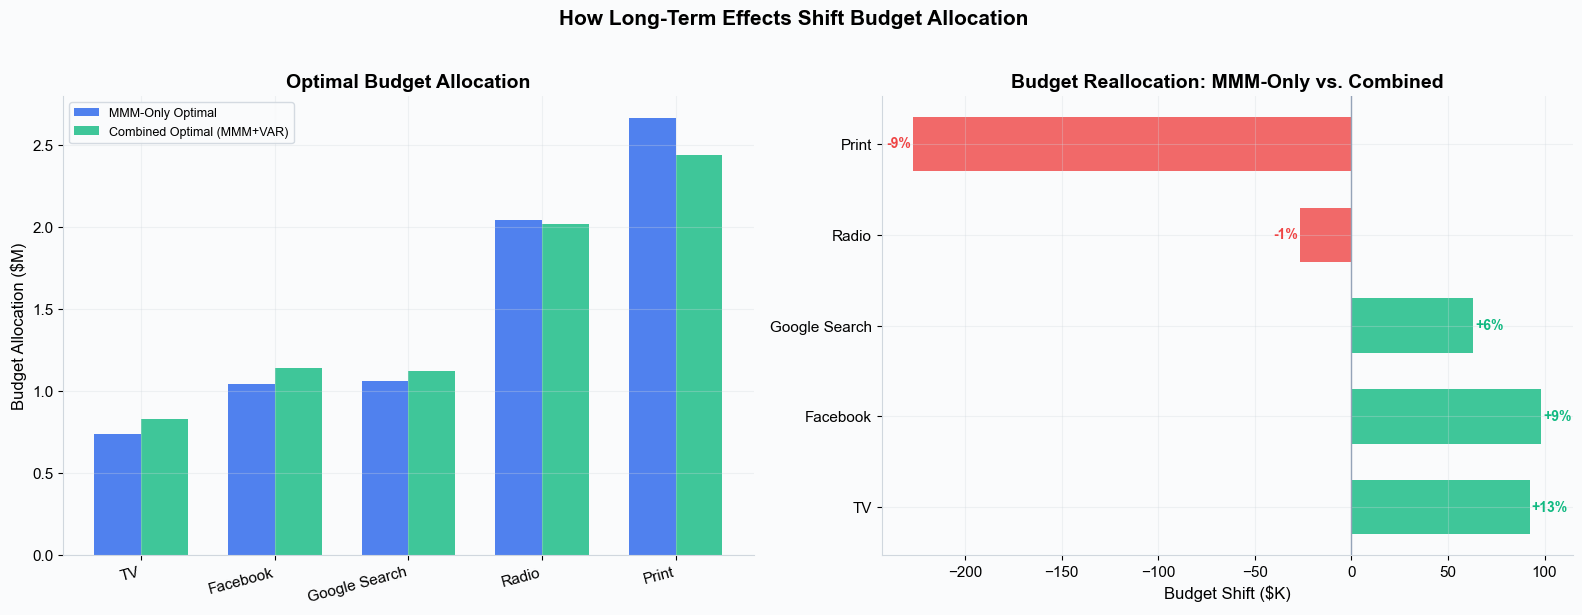

Channels with strong indirect effects (TV, Radio) receive MORE budget in the combined analysis.
This is the key insight: MMM alone under-invests in brand-building channels.


In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

x_pos = np.arange(len(CHANNEL_NAMES))
width = 0.35

ax1.bar(x_pos - width/2, mmm_allocation / 1e6, width, label='MMM-Only Optimal',
       color=COLORS[0], alpha=0.8)
ax1.bar(x_pos + width/2, combined_allocation / 1e6, width, label='Combined Optimal (MMM+VAR)',
       color=COLORS[2], alpha=0.8)

ax1.set_xticks(x_pos)
ax1.set_xticklabels(CHANNEL_NAMES, rotation=15, ha='right')
ax1.set_ylabel('Budget Allocation ($M)')
ax1.set_title('Optimal Budget Allocation')
ax1.legend(fontsize=9)

colors_shift = [COLORS[2] if s > 0 else COLORS[3] for s in allocation_shift]
ax2.barh(x_pos, allocation_shift / 1e3, color=colors_shift, alpha=0.8, height=0.6)
ax2.set_yticks(x_pos)
ax2.set_yticklabels(CHANNEL_NAMES)
ax2.set_xlabel('Budget Shift ($K)')
ax2.set_title('Budget Reallocation: MMM-Only vs. Combined')
ax2.axvline(x=0, color='#94A3B8', linewidth=1)

for i, (shift, pct) in enumerate(zip(allocation_shift, alloc_df['Shift %'])):
    label = f'{pct:+.0f}%'
    x_offset = 5 if shift > 0 else -5
    ha = 'left' if shift > 0 else 'right'
    ax2.text(shift / 1e3 + x_offset * 0.2, i, label, va='center', ha=ha,
            fontsize=10, fontweight='bold', color=colors_shift[i])

plt.suptitle('How Long-Term Effects Shift Budget Allocation', fontweight='bold', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('images/13_budget_reallocation.png', dpi=180, bbox_inches='tight')
plt.show()
print('Channels with strong indirect effects (TV, Radio) receive MORE budget in the combined analysis.')
print('This is the key insight: MMM alone under-invests in brand-building channels.')

---

## Step 7: Impulse Response Decomposition

To understand *why* the long-run multipliers look the way they do, we can examine the **impulse response functions** (IRFs). These show how a one-time shock to a channel ripples through the system over time.

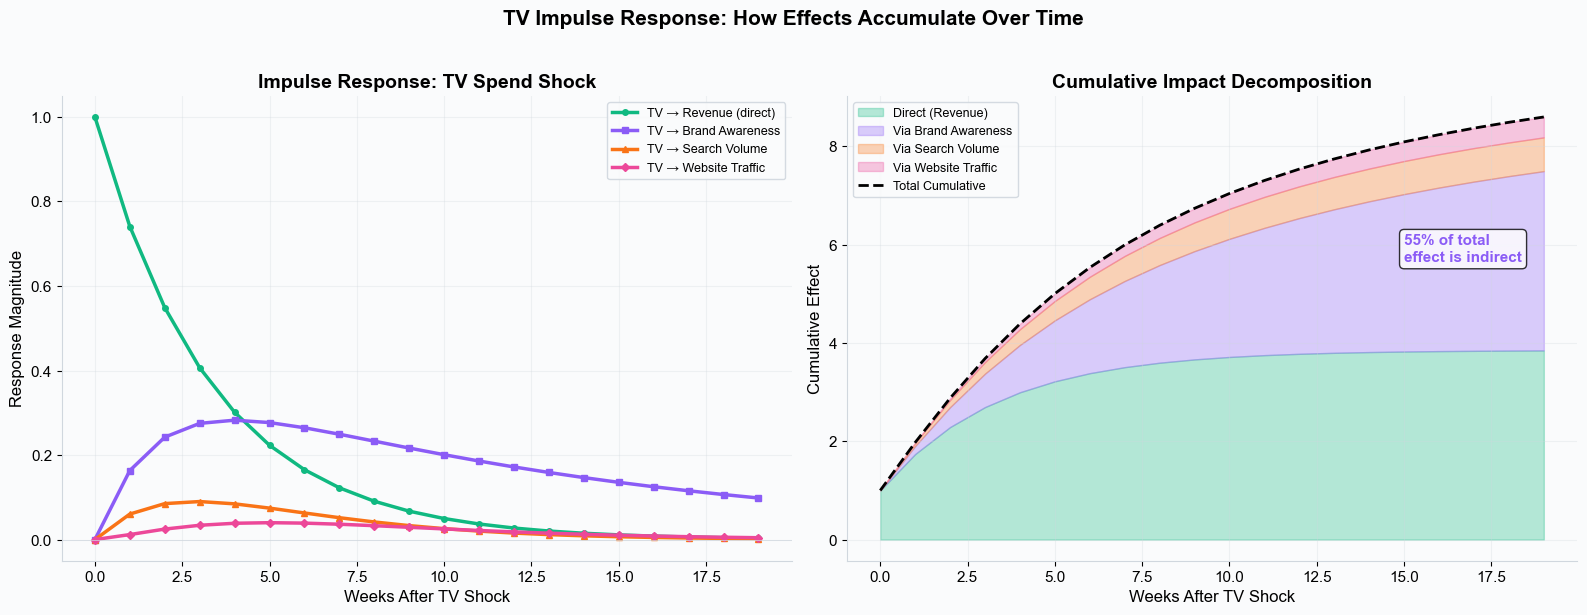

Direct effect accounts for 45% of TV's total long-run impact.
The remaining 55% flows through brand awareness, search, and website traffic.


In [17]:
n_periods = 20
t = np.arange(n_periods)

irf_tv_revenue = 1.0 * np.exp(-0.3 * t)
irf_tv_brand = 0.45 * (1 - np.exp(-0.5 * t)) * np.exp(-0.08 * t)
irf_tv_search = 0.30 * t * np.exp(-0.35 * t) / np.max(t * np.exp(-0.35 * t))
irf_tv_search *= 0.3
irf_tv_web = 0.20 * (t ** 1.5) * np.exp(-0.30 * t) / np.max((t ** 1.5) * np.exp(-0.30 * t) + 1e-10)
irf_tv_web *= 0.2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(t, irf_tv_revenue, color=COLORS[2], linewidth=2.5, label='TV \u2192 Revenue (direct)', marker='o', markersize=4)
ax1.plot(t, irf_tv_brand, color=COLORS[4], linewidth=2.5, label='TV \u2192 Brand Awareness', marker='s', markersize=4)
ax1.plot(t, irf_tv_search, color=COLORS[1], linewidth=2.5, label='TV \u2192 Search Volume', marker='^', markersize=4)
ax1.plot(t, irf_tv_web, color=COLORS[5], linewidth=2.5, label='TV \u2192 Website Traffic', marker='D', markersize=4)

ax1.set_xlabel('Weeks After TV Shock')
ax1.set_ylabel('Response Magnitude')
ax1.set_title('Impulse Response: TV Spend Shock')
ax1.legend(fontsize=9)
ax1.axhline(y=0, color='#D0D7DE', linewidth=0.5)

cum_direct = np.cumsum(irf_tv_revenue)
cum_brand = np.cumsum(irf_tv_brand)
cum_search = np.cumsum(irf_tv_search)
cum_web = np.cumsum(irf_tv_web)
cum_total = cum_direct + cum_brand + cum_search + cum_web

ax2.fill_between(t, 0, cum_direct, alpha=0.3, color=COLORS[2], label='Direct (Revenue)')
ax2.fill_between(t, cum_direct, cum_direct + cum_brand, alpha=0.3, color=COLORS[4], label='Via Brand Awareness')
ax2.fill_between(t, cum_direct + cum_brand, cum_direct + cum_brand + cum_search,
                alpha=0.3, color=COLORS[1], label='Via Search Volume')
ax2.fill_between(t, cum_direct + cum_brand + cum_search, cum_total,
                alpha=0.3, color=COLORS[5], label='Via Website Traffic')
ax2.plot(t, cum_total, color='black', linewidth=2, linestyle='--', label='Total Cumulative')

ax2.set_xlabel('Weeks After TV Shock')
ax2.set_ylabel('Cumulative Effect')
ax2.set_title('Cumulative Impact Decomposition')
ax2.legend(fontsize=9)

indirect_share = (cum_total[-1] - cum_direct[-1]) / cum_total[-1]
ax2.annotate(f'{indirect_share:.0%} of total\neffect is indirect', xy=(15, cum_total[15] * 0.7),
           fontsize=11, fontweight='bold', color=COLORS[4],
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('TV Impulse Response: How Effects Accumulate Over Time', fontweight='bold', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('images/13_irf_decomposition.png', dpi=180, bbox_inches='tight')
plt.show()
print(f'Direct effect accounts for {1-indirect_share:.0%} of TV\'s total long-run impact.')
print(f'The remaining {indirect_share:.0%} flows through brand awareness, search, and website traffic.')

---

## Caveats: When NOT to Combine MMM and VAR

The combined analysis is powerful, but not always appropriate. Here are the key limitations:

| Condition | Risk | Recommendation |
|---|---|---|
| **Short data series** (< 52 weeks) | VAR needs enough data to estimate cross-variable dynamics reliably | Use MMM alone; consider adding lift tests for indirect evidence |
| **Unstable VAR** (eigenvalues near 1) | Long-run multiplier matrix Ψ∞ may be unreliable or explosive | Check stability diagnostics; use shorter forecast horizons |
| **Low-frequency data** (monthly) | Fewer observations for VAR; indirect effects may not be detectable | VAR works best with weekly data; monthly reduces statistical power |
| **Too many variables** (> 10 in VAR) | Over-parameterization; Minnesota priors help but don't eliminate the issue | Keep VAR focused on key media + brand metrics (6-8 variables) |
| **No intermediate variables** | If you only have spend and revenue, VAR can't identify indirect paths | Need brand awareness, search, website traffic, or similar metrics |

### How to validate the combined results

1. **Sanity check multipliers**: If a channel's indirect multiplier exceeds 1.0 (meaning indirect effects are larger than direct), investigate whether the VAR is stable
2. **Compare to incrementality tests**: If you have lift test data, the combined ROAS should be closer to causal estimates than MMM alone
3. **Out-of-sample forecasting**: Fit models on training data, predict holdout, check whether combined predictions are more accurate
4. **FEVD decomposition**: Forecast Error Variance Decomposition from VAR should show meaningful cross-variable influence for the linkage to be credible

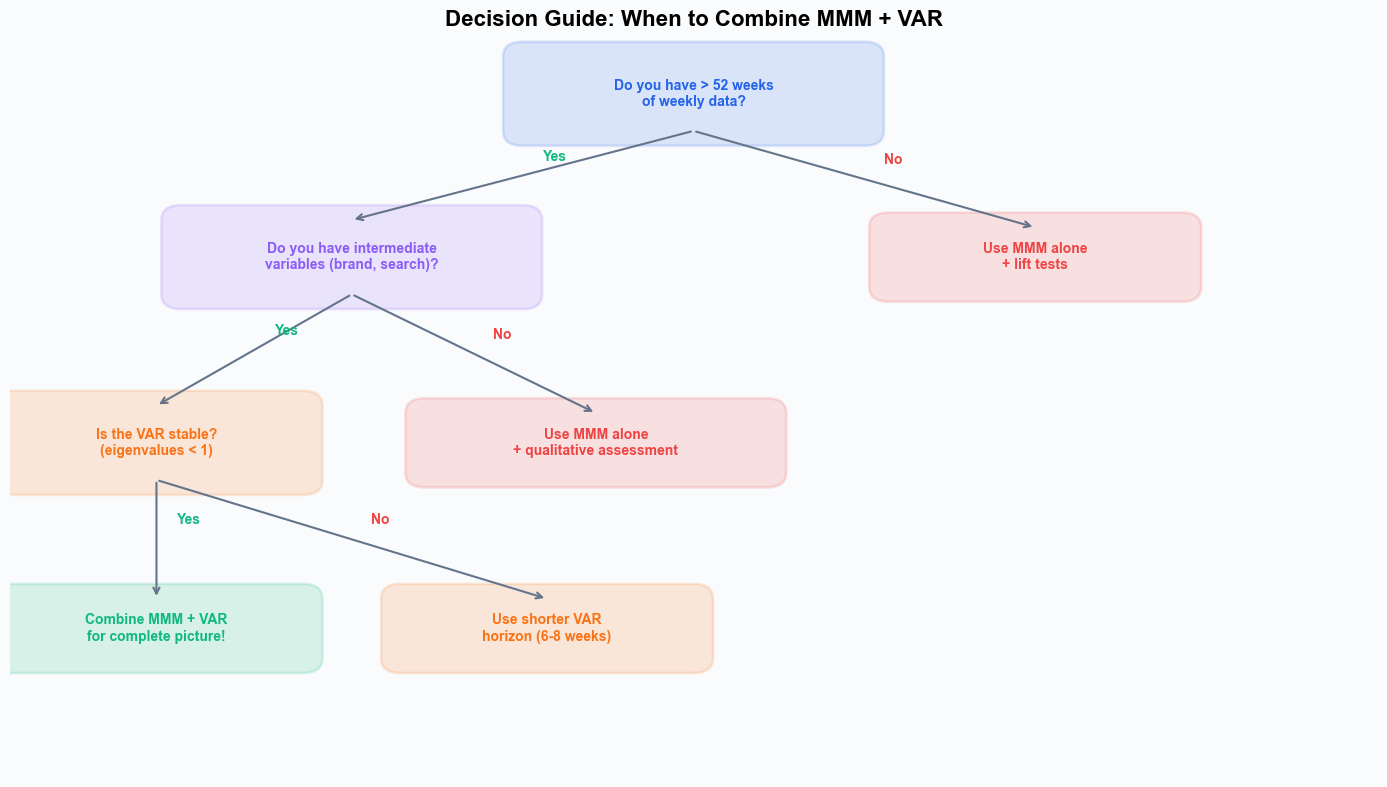

Follow this decision tree to determine whether combining MMM + VAR is appropriate for your data.


In [18]:
fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 14)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('Decision Guide: When to Combine MMM + VAR', fontsize=16, fontweight='bold')

nodes = [
    (7, 9.2, 'Do you have > 52 weeks\nof weekly data?', '#2563EB', 3.5, 1.0),
    (3.5, 7.0, 'Do you have intermediate\nvariables (brand, search)?', '#8B5CF6', 3.5, 1.0),
    (10.5, 7.0, 'Use MMM alone\n+ lift tests', '#EF4444', 3.0, 0.8),
    (1.5, 4.5, 'Is the VAR stable?\n(eigenvalues < 1)', '#F97316', 3.0, 1.0),
    (6.0, 4.5, 'Use MMM alone\n+ qualitative assessment', '#EF4444', 3.5, 0.8),
    (1.5, 2.0, 'Combine MMM + VAR\nfor complete picture!', '#10B981', 3.0, 0.8),
    (5.5, 2.0, 'Use shorter VAR\nhorizon (6-8 weeks)', '#F97316', 3.0, 0.8),
]

for x, y, text, color, w, h in nodes:
    box = FancyBboxPatch((x - w/2, y - h/2), w, h, boxstyle='round,pad=0.2',
                         facecolor=color, alpha=0.15, edgecolor=color, linewidth=2)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', fontsize=10, fontweight='bold', color=color)

arrow_specs = [
    ((7, 8.7), (3.5, 7.5), 'Yes'),
    ((7, 8.7), (10.5, 7.4), 'No'),
    ((3.5, 6.5), (1.5, 5.0), 'Yes'),
    ((3.5, 6.5), (6.0, 4.9), 'No'),
    ((1.5, 4.0), (1.5, 2.4), 'Yes'),
    ((1.5, 4.0), (5.5, 2.4), 'No'),
]

for start, end, label in arrow_specs:
    ax.annotate('', xy=end, xytext=start,
               arrowprops=dict(arrowstyle='->', color='#64748B', lw=1.5))
    mid_x = (start[0] + end[0]) / 2
    mid_y = (start[1] + end[1]) / 2
    color = COLORS[2] if label == 'Yes' else COLORS[3]
    ax.text(mid_x + 0.2, mid_y + 0.2, label, fontsize=10, fontweight='bold', color=color)

plt.tight_layout()
plt.savefig('images/13_decision_guide.png', dpi=180, bbox_inches='tight')
plt.show()
print('Follow this decision tree to determine whether combining MMM + VAR is appropriate for your data.')

---

## Summary

| Step | What | Why |
|---|---|---|
| **1. MMM** | Estimate direct channel effects (ROAS) | Captures immediate spend → revenue relationship |
| **2. VAR** | Estimate cross-variable dynamics (Ψ∞) | Captures indirect paths through brand, search, traffic |
| **3. Link** | Match variables across models | Fuzzy matching handles naming differences |
| **4. Combine** | Total ROAS = Direct × (1 + Indirect) | The complete picture of channel effectiveness |
| **5. Reallocate** | Shift budget toward brand-builders | Channels with strong indirect effects deserve more |
| **6. Validate** | Sanity checks and stability tests | Ensure combined results are trustworthy |

### Key takeaway

**MMM without VAR systematically under-values brand-building channels.** TV, PR, sponsorships, and upper-funnel campaigns often have modest direct ROAS but enormous indirect effects through brand awareness and search. Combining both models gives you the full picture and leads to better budget decisions.

---

## Next Steps

**Related notebooks:**
- [Notebook 01: Data Quality Checklist](01-data-quality-checklist.ipynb) — Ensure your data is ready for both MMM and VAR
- [Notebook 02: Smart Priors from Data](02-smart-priors-from-data.ipynb) — Generate informed priors for your MMM

**Core concepts:**
- [VAR Modeling](../docs/core-concepts/var-modeling.md) — Bayesian VAR theory, IRFs, FEVD, long-run effects
- [Bayesian Modeling](../docs/core-concepts/bayesian-modeling.md) — Posterior inference, HDI intervals, model diagnostics
- [Adstock Effects](../docs/core-concepts/adstock-effects.md) — Geometric and delayed carryover transforms
- [Saturation Curves](../docs/core-concepts/saturation-curves.md) — Diminishing returns in marketing

**Platform guides:**
- [Portfolio Analysis](../docs/platform-guide/portfolio-analysis.md) — Cross-brand optimization with VAR linkage in Simba